# 1 month salt budget test for panant-01, shelf only

From the experiment https://github.com/julia-neme/ssp126_sofia_experiments/tree/panant-ssp126-sofia.  
Trying to see whether salinity change on shelf is primarily from advection vs surface fluxes.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output091/*.ocean_month.nc'))
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output091/*.ocean_month_z.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['wfo','lrunoff']].sel(yh=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['so','S_advection_xy','Sh_tendency_vert_remap','osalttend','osaltpmdiff','osaltdiff','boundary_forcing_salt_tendency']].sel(yh=lat_slice)
    return ds

pan = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')
pan_z = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto')

In [4]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [5]:
depth = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom6_01')

In [6]:
lhs_salt = {
    'salt_tendency': pan_z.osalttend
}

rhs_salt = {
    # Advection
    'advection_xy': pan_z.S_advection_xy,
    'advection_vert': pan_z.Sh_tendency_vert_remap,

    # Diffusion / mixing
    'vertical_diffusion': pan_z.osaltdiff,
    'neutral_diffusion': pan_z.osaltpmdiff,

    # Surface & boundary forcing
    'surface_forcing': pan_z.boundary_forcing_salt_tendency,
}

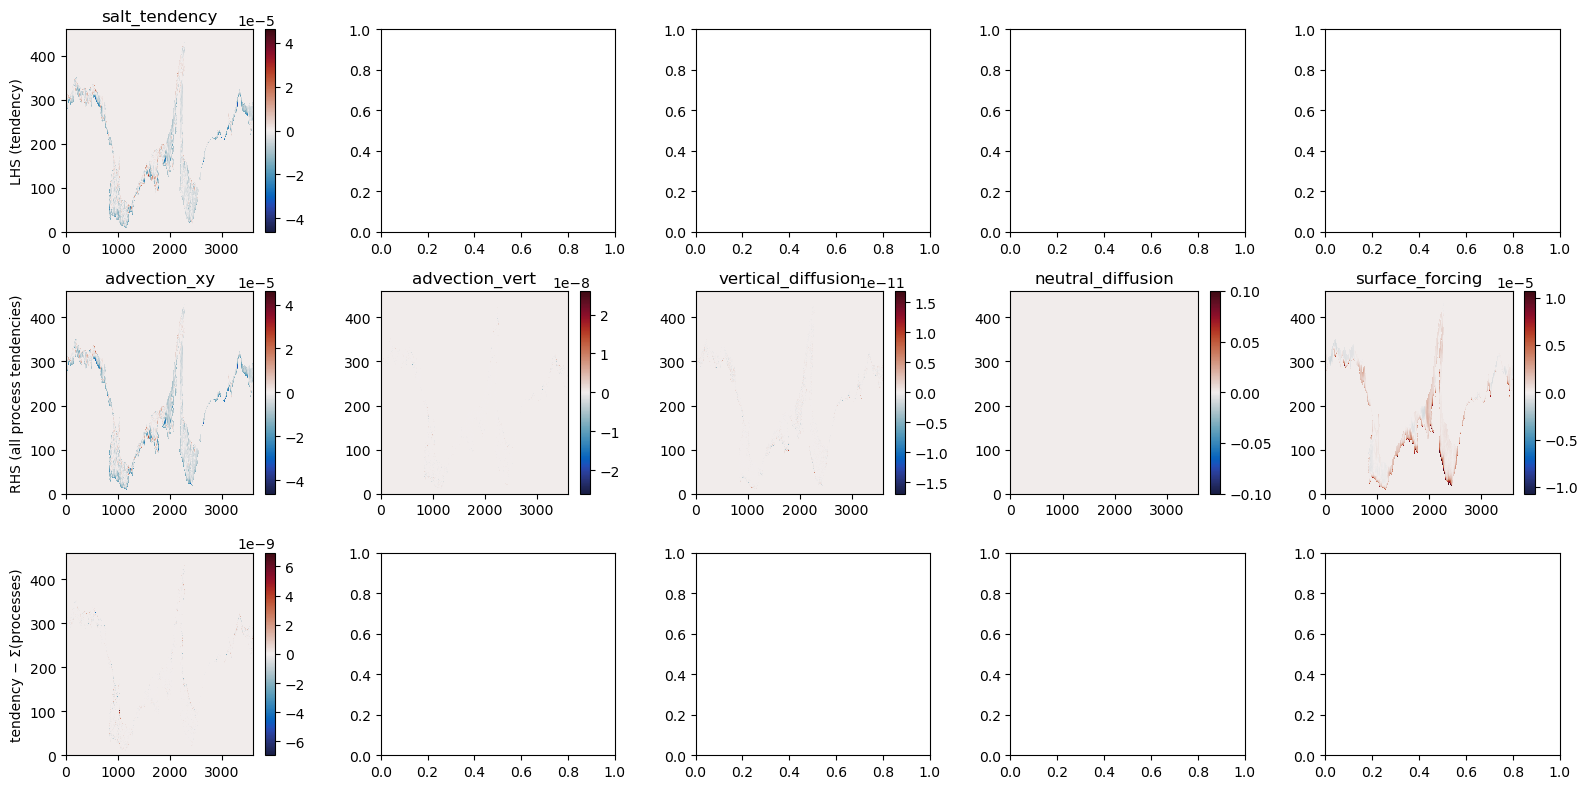

In [7]:
zdim = 'z_l'  # MOM6 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    da2d = da_masked.sum(zdim).squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[0, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    da2d = da_masked.sum(zdim).squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[1, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)

# -----------------------
# Closure residual
# -----------------------
lhs_total = pan_z.osalttend.where(shelf_mask == 1)

rhs_total = (
    pan_z.S_advection_xy
    + pan_z.Sh_tendency_vert_remap
    + pan_z.boundary_forcing_salt_tendency
    + pan_z.osaltdiff
    + pan_z.osaltpmdiff
).where(shelf_mask == 1)

residual = (lhs_total - rhs_total).sum(zdim).squeeze()

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()

vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance,
    vmin=-vmax, vmax=vmax
)

plt.colorbar(im, ax=ax[2, 0])

# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms.   
We also want to check whether there is off-shelf advection.  

In [8]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yh: 460, xh: 3600)> Size: 7MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * yh       (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
    time     object 8B 2001-01-16 12:00:00

In [9]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(6.9424857e-09)
Coordinates:
    time     object 8B 2001-01-16 12:00:00

In [10]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(-6.94800928e-09)
Coordinates:
    time     object 8B 2001-01-16 12:00:00

So budget is closed. Can we approximate to **tendency = advection + surface forcing**? Check relative magnitude of LHS terms. 

In [11]:
# testing individual diagnostics
tendency = pan_z.osalttend
adv_horizontal = pan_z.S_advection_xy
adv_vertical = pan_z.Sh_tendency_vert_remap
surface_forcing = pan_z.boundary_forcing_salt_tendency
diff_1 = pan_z.osaltdiff
diff_2 = pan_z.osaltpmdiff

In [12]:
tendency_plot = tendency.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_hor_plot = adv_horizontal.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_vert_plot = adv_vertical.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
surface_plot = surface_forcing.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_1_plot = diff_1.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_2_plot = diff_2.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()

In [13]:
tendency_plot = tendency_plot.compute()
adv_hor_plot = adv_hor_plot.compute()
adv_vert_plot = adv_vert_plot.compute()

In [14]:
surface_plot = surface_plot.compute()
diff_1_plot = diff_1_plot.compute()
diff_2_plot = diff_2_plot.compute()

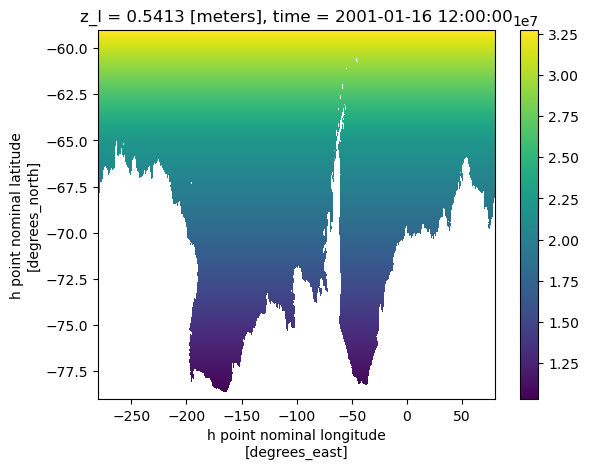

In [15]:
# Doing spatial average
area = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['areacello']
var = pan_z.so.isel(time=0,z_l=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [16]:
tendency_ave = (area_corr * tendency_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_hor_ave = (area_corr * adv_hor_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_vert_ave = (area_corr * adv_vert_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
surface_ave = (area_corr * surface_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_1_ave = (area_corr * diff_1_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_2_ave = (area_corr * diff_2_plot).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

In [17]:
tendency_ave = tendency_ave.load()
adv_hor_ave = adv_hor_ave.load()
tendency_ave = tendency_ave.load()
tendency_ave = tendency_ave.load()
tendency_ave = tendency_ave.load()
tendency_ave = tendency_ave.load()

**On average, how much salt per square metre is being added/removed from the shelf (full-depth integrated), due to...**

In [18]:
print("tendency =", tendency_ave.values, "\nhorizontal advection =", adv_hor_ave.values, "\nvertical advection =", adv_vert_ave.values, "\nsurface forcing =", 
      surface_ave.values, "\ndiffusion 1 =", diff_1_ave.values, "\ndiffusion 2 =", diff_2_ave.values)

tendency = -2.9939295e-06 
horizontal advection = -3.6050465e-06 
vertical advection = -9.528022e-13 
surface forcing = 6.111175e-07 
diffusion 1 = 5.448829e-16 
diffusion 2 = 0.0


So yes, tendency, horizontal advection, and surface forcing are the dominant terms.  
We also see that the tendency is dominated by horizontal advection, far more than surface forcing.  
**BUT** this is just the meltwater experiment. We need to look at the anomaly (pert - control) to see what's actually happening.

In [19]:
# Checking closure again
print("LHS =", tendency_ave.values, "\nRHS =", (adv_hor_ave + adv_vert_ave + surface_ave + diff_1_ave + diff_2_ave).values)

LHS = -2.9939295e-06 
RHS = -2.99393e-06


Pretty close!